# SAMOSA Tutorial: Multilevel Markov chain Monte Carlo Sampling

This notebook demonstrates how to set up and run a full-scale multi-fidelity Bayesian inference problem using the Multilevel Monte Carlo algorithm. The MLMC estimator is given by
$$
\hat{Q}^{\text{MLMC}} = \hat{Q}_0 + \sum_{\ell=1}^{L} \left(\hat{Q}_{\ell} - \hat{Q}_{\ell-1}\right)
$$
where $\hat{Q}_{\ell}$ is the $\ell$'th level Monte Carlo estimate. Therefore the above equation can be written as
$$
\hat{Q}^{\text{MLMC}} = \frac{1}{N_0}\sum_{i=1}^{N_0}Q_{0}(\theta_0^i) + \sum_{\ell=1}^{L} \left(\frac{1}{N_{\ell}}\sum_{i=1}^{N_{\ell}}\left(Q_{\ell}(\theta_{\ell}^i) - Q_{\ell-1}(\vartheta_{\ell-1}^i)\right)\right)
$$
The goal is to reduce the variance of the difference term in the RHS $Q_{\ell}(\theta_{\ell}^i) - Q_{\ell-1}(\vartheta_{\ell-1}^i)$ by correlating $\theta_{\ell}$ and $\vartheta_{\ell-1}$.

## 1. Model definition

We will consider the family of multi-fidelity 1D Gaussian posteriors parameterized by $\ell$ as 
$$
\mathcal{N}\left(2^{-\ell+2}, 1\right)
$$
These are Gaussians that shift from the right to the left upon increasing $\ell$ values.

In [1]:
# Some imports
import numpy as np
from samosa.utils.tools import lognormpdf
from typing import Any, Dict
import matplotlib.pyplot as plt

burnin = 0.25

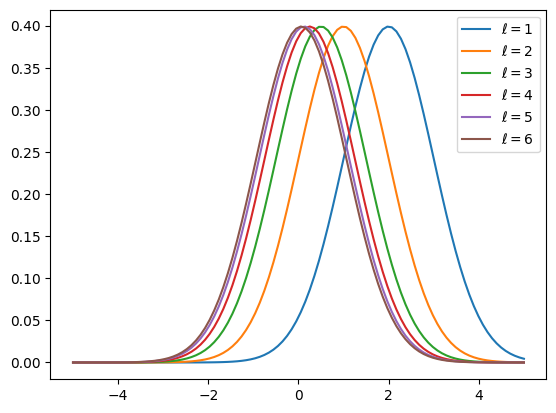

In [2]:
# Define the models and plot the true posteriors
def shifting_Gaussian(params: np.ndarray, ell: int, cost: float = 2) -> Dict[str, Any]:
    """
    Banana model: log posterior via log_banana (Rosenbrock-type), optional qoi and cost.
    """
    # log_banana from samosa.utils.tools — transformation y0=x0, y1=x1+x0^2; then N(0,I) in y
    lp = lognormpdf(params, mean=2 ** (-ell + 2), cov=np.eye(1))
    # ChainState expects scalar log_posterior when params is (d, 1)
    output = {
        "log_posterior": lp,
        "cost": float(cost**ell),
    }
    return output


# Plot the shifting_Gaussian contours to see what you're sampling from
xlims = [-5, 5]
x = np.linspace(xlims[0], xlims[1], 100)
for ell in range(1, 7):
    model = shifting_Gaussian(np.reshape(x, (1, -1)), ell)
    Z = np.exp(model["log_posterior"])
    plt.plot(x, Z, label=rf"$\ell={ell}$")
plt.legend()
plt.show()

## 2. Multi-fidelity sampling for MLMC

We use the provided utilities to build one kernel per level and run the sampler. Then we estimate MLMC statistics (mean, variance, correlations) and use the post-processor to visualize diagnostics per level.

Levels are independent and can be run in parallel; use MPI to distribute levels across cores for faster runs.

In [ ]:
# Build one kernel per level (level 0: MH with fine model; level > 0: CoupledKernel with coarse/fine)
from samosa import create_mlmc_levels, MLMCSampler, MLMCCalculator, MLMCPostProcessor
from samosa import CoupledKernel, MetropolisHastingsKernel
from samosa import GaussianRandomWalk, SynceCoupling

L = 3  # max level index: levels 0, 1, ..., L (i.e. L+1 levels)
proposal = GaussianRandomWalk(mu=np.zeros((1, 1)), cov=2.38**2 * np.eye(1))
# adapter = GlobalAdapter(target_ar=0.234, adapt_end=10000) # Optional adaptation
# proposal = AdaptiveProposal(proposal, adapter)
# Define the level wise kernels
# Level 0: MH with fine model
# Level 1, 2, ..., L: Coupled SYNCE kernel with coarse/fine models and coupled proposal
kernels = [
    MetropolisHastingsKernel(
        model=lambda params: shifting_Gaussian(params, ell=0), proposal=proposal
    ),
] + [
    CoupledKernel(
        coarse_model=lambda params: shifting_Gaussian(params, ell=ell - 1),
        fine_model=lambda params: shifting_Gaussian(params, ell=ell),
        coupled_proposal=SynceCoupling(proposal, proposal),
    )
    for ell in range(1, L + 1)
]
samples_per_level = [10000] * (L + 1)
initial_positions = [(None, np.random.randn(1, 1))] + [
    (np.random.randn(1, 1), np.random.randn(1, 1)) for _ in range(L)
]
levels = create_mlmc_levels(
    kernels=kernels,
    samples_per_level=samples_per_level,
    initial_positions=initial_positions,
)
mlmc = MLMCSampler(
    levels=levels, output_dir="mlmc_shifting_gaussian", print_progress=True
)
mlmc.run()

mlmc_calc = MLMCCalculator(
    output_dir="mlmc_shifting_gaussian", num_levels=L + 1, print_progress=True
)
mlmc_calc.compute_mlmc_estimator(burnin_fraction=burnin)
mlmc_calc.print_mlmc_summary()

mlmc_post = MLMCPostProcessor(output_dir="mlmc_shifting_gaussian", print_progress=True)
mlmc_post.process_levels(levels=list(range(L + 1)), burnin_fraction=burnin)

2026-02-26 15:04:43,656 - samosa.core.mlmc - INFO - MLMC Sampler Setup: 4 levels, 1 MPI processes
2026-02-26 15:04:43,656 - samosa.core.mlmc - INFO - Starting MLMC sampling...
2026-02-26 15:04:43,657 - samosa.core.mlmc - INFO - Total samples: [10000, 10000, 10000, 10000]
2026-02-26 15:04:43,657 - samosa.core.mlmc - INFO - Process 0: Starting level 0
2026-02-26 15:04:43,657 - samosa.core.mlmc - INFO - Sampling Level 0: 10000 samples (fine model only)
2026-02-26 15:04:43,658 - samosa.samplers.single_chain - INFO - Single-chain MCMC run starting: iterations=10000, start=1


Level distribution for post-processing across MPI processes:
  Process 0: levels [0, 1, 2, 3]


2026-02-26 15:04:44,392 - samosa.samplers.single_chain - INFO - Checkpoint saved: iteration=10000, path=mlmc_shifting_gaussian/level_0/samples.pkl
2026-02-26 15:04:44,393 - samosa.samplers.single_chain - INFO - Single-chain MCMC run finished: acceptance_rate=0.4431
2026-02-26 15:04:44,395 - samosa.core.mlmc - INFO - Process 0: Completed level 0 in 0.74s
2026-02-26 15:04:44,396 - samosa.core.mlmc - INFO - Process 0: Starting level 1
2026-02-26 15:04:44,396 - samosa.core.mlmc - INFO - Sampling Level 1: 10000 samples (coupled chains)
2026-02-26 15:04:44,396 - samosa.samplers.coupled_chain - INFO - Coupled-chain MCMC run starting: iterations=10000, start=1
2026-02-26 15:04:45,695 - samosa.samplers.coupled_chain - INFO - Checkpoint saved: iteration=10000, paths=mlmc_shifting_gaussian/level_1/samples_coarse.pkl, mlmc_shifting_gaussian/level_1/samples_fine.pkl
2026-02-26 15:04:45,695 - samosa.samplers.coupled_chain - INFO - Coupled-chain MCMC run finished: acceptance_rate_coarse=0.4480, accep

Level distribution for post-processing across MPI processes:
  Process 0: levels [0, 1, 2, 3]


2026-02-26 15:04:48,501 - samosa.core.mlmc - INFO - Process 0: Completed level 2
2026-02-26 15:04:48,501 - samosa.core.mlmc - INFO - Process 0: Processing level 3
2026-02-26 15:04:48,577 - samosa.core.mlmc - INFO - Process 0: Completed level 3
2026-02-26 15:04:48,578 - samosa.core.mlmc - INFO - ==================================================
2026-02-26 15:04:48,578 - samosa.core.mlmc - INFO - MLMC ESTIMATION COMPLETE
2026-02-26 15:04:48,578 - samosa.core.mlmc - INFO - Levels completed: [0, 1, 2, 3]
2026-02-26 15:04:48,578 - samosa.core.mlmc - INFO - Samples per level: [10000, 10000, 10000, 10000]
2026-02-26 15:04:48,579 - samosa.core.mlmc - INFO - Burnin fraction: 0.25
2026-02-26 15:04:48,579 - samosa.core.mlmc - INFO - MLMC expectation shape: (1,)
2026-02-26 15:04:48,579 - samosa.core.mlmc - INFO - MLMC variance shape: (1,)
2026-02-26 15:04:48,579 - samosa.core.mlmc - INFO - Results saved to: mlmc_shifting_gaussian/mlmc_results.pkl
2026-02-26 15:04:48,591 - samosa.core.mlmc - INFO 

Level distribution for post-processing across MPI processes:
  Process 0: levels [0, 1, 2, 3]


2026-02-26 15:04:49,396 - samosa.core.mlmc - INFO - Process 0: Level 0 completed
2026-02-26 15:04:49,396 - samosa.core.mlmc - INFO - Process 0: Processing level 1...
2026-02-26 15:04:51,130 - samosa.core.mlmc - INFO - Process 0: Level 1 completed
2026-02-26 15:04:51,131 - samosa.core.mlmc - INFO - Process 0: Processing level 2...
2026-02-26 15:04:52,434 - samosa.core.mlmc - INFO - Process 0: Level 2 completed
2026-02-26 15:04:52,435 - samosa.core.mlmc - INFO - Process 0: Processing level 3...
2026-02-26 15:04:53,929 - samosa.core.mlmc - INFO - Process 0: Level 3 completed
2026-02-26 15:04:53,930 - samosa.core.mlmc - INFO - ======================================================================
2026-02-26 15:04:53,930 - samosa.core.mlmc - INFO - POST-PROCESSING COMPLETE
2026-02-26 15:04:53,931 - samosa.core.mlmc - INFO - ======================================================================
